In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [2]:
home = 'images'
directories = 'train', 'test', 'val'
class_names = ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

In [3]:
def read_file_to_list(file_path):
    with open(file_path, 'r') as file:
        content = file.read().strip()
    return [int(char) for char in content]

In [4]:
y_train = read_file_to_list(f'{home}/{directories[0]}.txt')
y_test = read_file_to_list(f'{home}/{directories[1]}.txt')
y_val = read_file_to_list(f'{home}/{directories[2]}.txt')

In [5]:
train_folder = os.path.join(home, directories[0])
test_folder = os.path.join(home, directories[1])
val_folder = os.path.join(home, directories[2])

def get_image_content(folder_path):
    image_contents = []
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path):
            image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            image_contents.append(image)
    return image_contents

x_train = get_image_content(train_folder)
x_test = get_image_content(test_folder)
x_val = get_image_content(val_folder)

In [6]:
def to_histogram(photos: list, original=False):
    result = []
    for photo in photos:
        hist = np.histogram(photo, bins=256)[0]
        if original is True:
            hist[:5] = 0
        result.append(hist)
    return result

def to_lbp(photos: list, num_points: int = 8, radius: int = 1):
    result = []
    for photo in photos:
        result.append(feature.local_binary_pattern(photo, num_points, radius, method='uniform'))
    return result

def to_pca(photos: list, n_components: int):
    pca = PCA(n_components=n_components)
    conv_photos = np.array(photos).reshape(len(photos), -1)
    return pca.fit_transform(conv_photos), np.sum(pca.explained_variance_ratio_)

def to_sobel(photos: list):
    sobel = lambda image: filters.sobel(image)
    conv_photos = np.array(photos).reshape(len(photos), -1)
    result = [sobel(image) for image in conv_photos]
    return result

def to_clahe(photos: list, clip=5):
    result = []
    clahe = cv2.createCLAHE(clipLimit=clip)
    for photo in photos:
        final_img = clahe.apply(photo) + 30
        result.append(final_img)
    return result


Image histogram

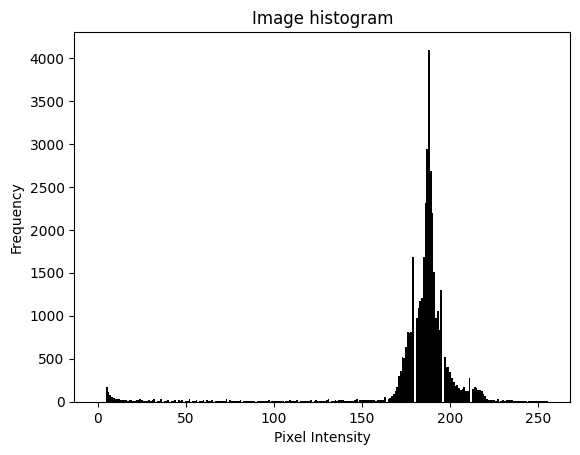

In [7]:
hist = np.histogram(x_train[0], bins=256)[0]
hist[:5] = 0
plt.bar(range(256), hist, width=1.0, color='black')
plt.title('Image histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

In [18]:
def train_classifier(classifier, param_grid, x_train, cv = 5):
    grid_search = GridSearchCV(classifier, param_grid, cv=cv, verbose=0)
    grid_search.fit(x_train, y_train)
    best_model = grid_search.best_estimator_
    return best_model, grid_search.best_params_

def evaluate(classifiers, x_train, x_val):
  for classifier, param_grid in classifiers:
    best_model, best_params = train_classifier(classifier, param_grid, x_train)
    y_pred = best_model.predict(x_val)

    print(f'{classifier.__class__.__name__}')
    print('Best Parameters:', best_params)
    print(classification_report(y_val, y_pred, target_names=class_names, digits=4))
    sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, xticklabels=class_names, yticklabels=class_names, fmt='d')
    plt.show()

In [8]:
svm_param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
rf_param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
knn_param_grid = {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
adaboost_param_grid = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]}
xgboost_param_grid = {'n_estimators': [50, 100, 150],
                    'max_depth': [3, 4, 5]}
classifiers = [
    (SVC(), svm_param_grid),
    (RandomForestClassifier(), rf_param_grid),
    (KNeighborsClassifier(), knn_param_grid),
    (AdaBoostClassifier(), adaboost_param_grid),
     (xgb.XGBClassifier(), xgboost_param_grid)
]

In [9]:
x_train_hist = to_histogram(x_train, original=True)
x_test_hist = to_histogram(x_test, original=True)
x_val_hist = to_histogram(x_val, original=True)

In [ ]:
evaluate(classifiers, x_train_hist, x_val_hist)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
